# Inner Swath example

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import plotly.graph_objects as go

from swot_toolkit.analysis import open_sites_and_dates


In [2]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray as xrio
import xarray as xr

from swot_toolkit.flags import mask_by_flags
from swot_toolkit.pipe2 import open_output_dir
from swot_toolkit.pipe4 import create_swot_mosaic
from swot_toolkit.swot import (
    get_nadir_from_footprint,
    get_nadir_from_raster,
    get_raster_footprint,
    get_swot_footprint,
)


In [9]:
REGION = "Rio_Negro"
DATE = "2025-05-15"

regions_dates = [
    {"REGION": "Rio_Branco", "DATE": "2025-09-07"},
    {"REGION": "Curua-Una", "DATE": "2025-08-14"},
    {"REGION": "Rio_Negro", "DATE": "2025-08-07"},
    {"REGION": "Northeast", "DATE": "2025-07-20"},
]

DOWNLOAD_FOLDER = Path("/data/swot/downloads")

/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM20M_N_x_x_x_032_395_075F_20250512T030606_20250512T030627_PID0_01.nc
/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM20M_N_x_x_x_032_548_079F_20250517T141847_20250517T141908_PID0_01.nc
/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM20M_N_x_x_x_032_548_080F_20250517T141907_20250517T141928_PID0_01.nc


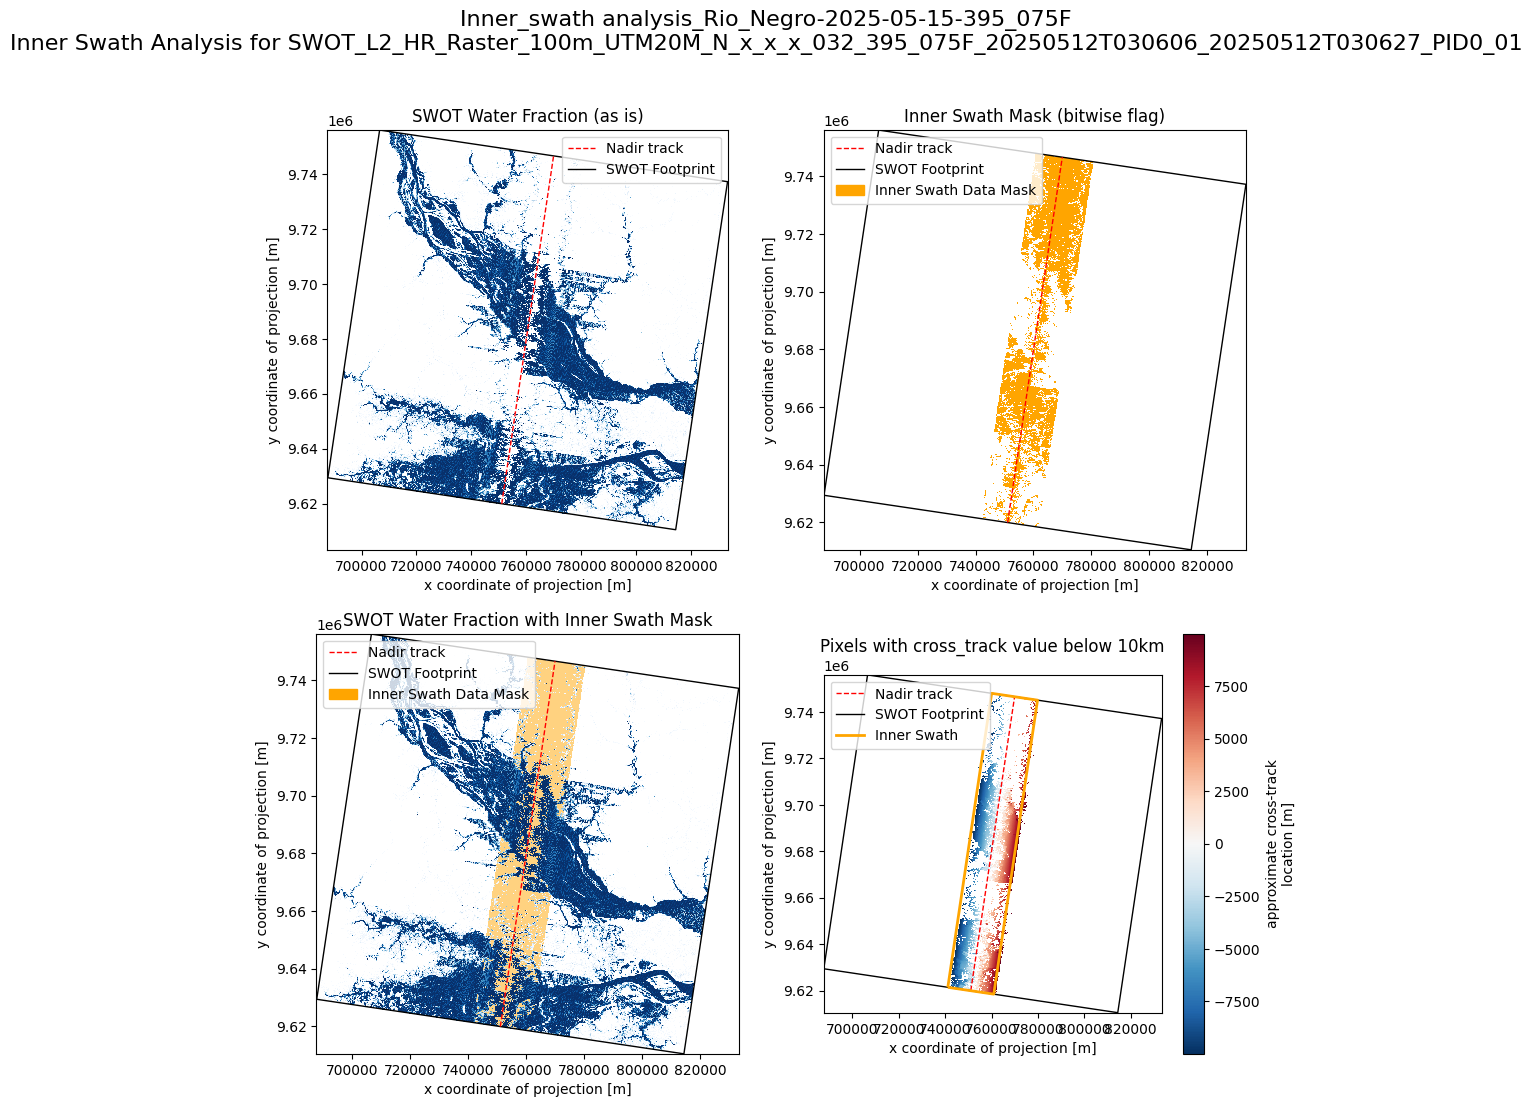

In [10]:
from swot_toolkit.analysis import plot_inner_swath_analysis

figs = plot_inner_swath_analysis(REGION, DATE)
figs[0]

## Plot Sample Figures Appendix

6


Text(0.5, 1.0, 'SWOT Water Fraction (no filtering)\nBrazil semi-arid - Scene: 421_071F (2025-04-01)')

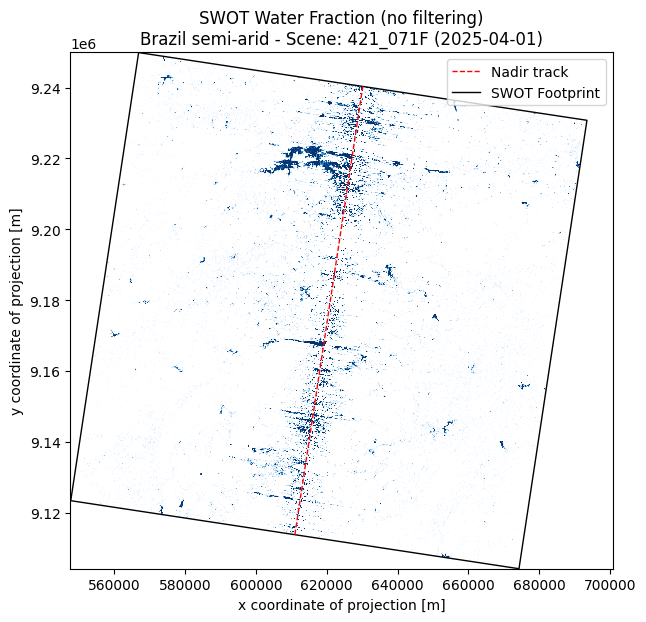

In [53]:
from swot_toolkit.analysis import get_swot_scenes_by_mosaic_dates, plot_water_fraction

sample = {
    "REGION": "Northeast",
    "DATE": "2025-04-07",
    "IDX": 4,
}


# sample = {
#     "REGION": "Rio_Madeira",
#     "DATE": "2025-01-25",
#     "IDX": 0,
# }

# sample = {
#     "REGION": "Rio_Negro",
#     "DATE": "2025-05-15",
#     "IDX": 1,
# }


REGION = sample["REGION"]
DATE = sample["DATE"]
IDX = sample["IDX"]

mosaic_files, mosaic_items = get_swot_scenes_by_mosaic_dates(REGION, DATE)

print(len(mosaic_files))
ds = xrio.open_rasterio(mosaic_files[IDX], mask_and_scale=True)

fig, ax = plt.subplots(figsize=(7, 7))
plot_water_fraction(ds, ax=ax, add_colorbar=False)

title = "SWOT Water Fraction (no filtering)\n"
region = REGION.replace("_", " ").replace("Northeast", "Brazil semi-arid")
scene_date = mosaic_items.iloc[IDX]["date"]
title += f"{region} - Scene: {mosaic_items.index[IDX]} ({scene_date})"
ax.set_title(title)

In [51]:
mosaic_files[IDX]

'/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_027_089_073F_20250116T205717_20250116T205738_PIC2_01.nc'

## No pixels FLAG

In [5]:
import earthaccess

from swot_toolkit.pipe2 import open_roi

base_dir, aoi, mosaic_df = open_roi(REGION)


Reading KML file: /data/swot/output/Rio_Branco/kml/Rio_Branco.kml


In [6]:
mosaic_df.head()

cycle_id pass_id tile_id         date_str     vers  \
mosaic_date tile_name                                                      
2024-01-11  117_077F       009     117    077F  20240108T072742  PIC0_01   
            270_078F       009     270    078F  20240113T183922  PIC0_01   
2024-01-31  117_077F       010     117    077F  20240129T041248  PIC0_01   
            270_078F       010     270    078F  20240203T152428  PIC0_01   
2024-02-21  117_077F       011     117    077F  20240219T005753  PIC0_01   

                                 datetime        date  \
mosaic_date tile_name                                   
2024-01-11  117_077F  2024-01-08 07:27:42  2024-01-08   
            270_078F  2024-01-13 18:39:22  2024-01-13   
2024-01-31  117_077F  2024-01-29 04:12:48  2024-01-29   
            270_078F  2024-02-03 15:24:28  2024-02-03   
2024-02-21  117_077F  2024-02-19 00:57:53  2024-02-19   

                                                               native-id  \
mosaic_date tile_name                                                      
2024-01-11  117_077F   SWOT_L2_HR_Raster_100m_UTM20M_N_x_x_x_009_117_...   
            270_078F   SWOT_L2_HR_Raster_100m_UTM20M_N_x_x_x_009_270_...   
2024-01-31  117_077F   SWOT_L2_HR_Raster_100m_UTM20M_N_x_x_x_010_117_...   
            270_078F   SWOT_L2_HR_Raster_100m_UTM20M_N_x_x_x_010_270_...   
2024-02-21  117_077F   SWOT_L2_HR_Raster_100m_UTM20M_N_x_x_x_011_117_...   

                                                                     url  
mosaic_date tile_name                                                     
2024-01-11  117_077F   https://archive.swot.podaac.earthdata.nasa.gov...  
            270_078F   https://archive.swot.podaac.earthdata.nasa.gov...  
2024-01-31  117_077F   https://archive.swot.podaac.earthdata.nasa.gov...  
            270_078F   https://archive.swot.podaac.earthdata.nasa.gov...  
2024-02-21  117_077F   https://archive.swot.podaac.earthdata.nasa.gov...

In [ ]:
mosaic_files = earthaccess.download(
    mosaic_df.loc[DATE]["url"].to_list(),
    local_path=DOWNLOAD_FOLDER,
    pqdm_kwargs={"disable": True},
)


In [16]:
IDX = 0
file = mosaic_files[IDX]
ds = xrio.open_rasterio(file, mask_and_scale=True)


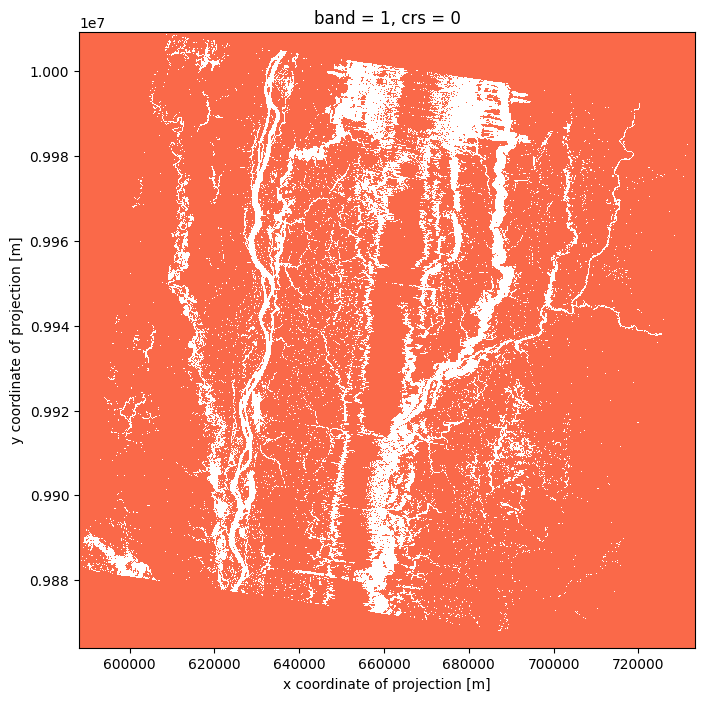

In [ ]:
import matplotlib.pyplot as plt

from swot_toolkit.analysis import plot_water_fraction
from swot_toolkit.flags import mask_by_flags

# Create the no pixels mask
no_pixels_np = mask_by_flags(ds["water_area_qual_bitwise"], flags=["no_pixels"])
no_pixels = ds["water_frac"].copy()
no_pixels.data = no_pixels_np
no_pixels = no_pixels.where(no_pixels != 0).squeeze()


fig, ax = plt.subplots(figsize=(10, 8))
# plot_water_fraction(ds, ax=ax, add_colorbar=False)

no_pixels.plot.imshow(ax=ax, cmap="Reds", alpha=1.0, add_colorbar=False)
ax.set_aspect("equal")
# ax.imshow(no_pixels.squeeze(), cmap="Reds", alpha=0.5)

In [27]:
no_pixels.all()

<xarray.DataArray 'water_frac' ()> Size: 1B
array(True)
Coordinates:
    band     int64 8B 1
    crs      int64 8B 0

# SCRATCH

In [53]:
from swot_toolkit.swot import create_raster_mosaic_2, create_raster_mosaic_combined

raster2, patches2, no_data_mask2 = create_raster_mosaic_2(
    mosaic_df=mosaic_df,
    ref_date="2024-01-11",
    aoi=aoi,
)


In [55]:
mosaic_df.loc["2024-01-11"]

,cycle_id,pass_id,tile_id,date_str,vers,datetime,date,native-id,url
tile_name,,,,,,,,,
117_077F,009,117,077F,20240108T072742,PIC0_01,2024-01-08 07:27:42,2024-01-08,SWOT_L2_HR_Raster_100m_UTM20M_N_x_x_x_009_117_...,https://archive.swot.podaac.earthdata.nasa.gov...
270_078F,009,270,078F,20240113T183922,PIC0_01,2024-01-13 18:39:22,2024-01-13,SWOT_L2_HR_Raster_100m_UTM20M_N_x_x_x_009_270_...,https://archive.swot.podaac.earthdata.nasa.gov...


In [59]:
raster, patches, no_data_mask = create_raster_mosaic_combined(
    mosaic_df=mosaic_df,
    ref_date="2024-01-11",
    aoi=aoi,
)


In [67]:
np.where(raster2["water_frac"] != raster)

(array([  0,   0,   1, ..., 495, 495, 495], shape=(2482,)),
 array([254, 275,  42, ..., 333, 434, 437], shape=(2482,)))

In [46]:
concat = xr.concat(patches, dim="idx").squeeze()

In [49]:
concat["water_frac"].mean(dim="idx")

<xarray.DataArray 'water_frac' (y: 496, x: 483)> Size: 958kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(496, 483), dtype=float32)
Coordinates:
    crs          int64 8B 0
    band         int64 8B 1
    spatial_ref  int64 8B 0
  * x            (x) float64 4kB 6.068e+05 6.069e+05 ... 6.549e+05 6.55e+05
  * y            (y) float64 4kB 9.96e+06 9.96e+06 ... 9.911e+06 9.911e+06

In [19]:
ds = xrio.open_rasterio(file, mask_and_scale=True)


In [20]:
patch = ds[["water_frac", "water_area_qual", "water_area_qual_bitwise"]]

In [24]:
patch.compute()

<xarray.Dataset> Size: 34MB
Dimensions:                  (band: 1, y: 1453, x: 1453)
Coordinates:
  * band                     (band) int64 8B 1
  * x                        (x) float64 12kB 5.881e+05 5.882e+05 ... 7.333e+05
  * y                        (y) float64 12kB 1.001e+07 1.001e+07 ... 9.864e+06
    crs                      int64 8B 0
Data variables:
    water_frac               (band, y, x) float32 8MB nan nan nan ... nan nan
    water_area_qual          (band, y, x) float32 8MB 3.0 3.0 3.0 ... 3.0 3.0
    water_area_qual_bitwise  (band, y, x) float64 17MB 8.053e+08 ... 8.053e+08
Attributes: (12/49)
    contact:                       podaac@podaac.jpl.nasa.gov
    Conventions:                   CF-1.7
    coordinate_reference_system:   Universal Transverse Mercator
    crid:                          PID0
    cycle_number:                  34
    descriptor_string:             100m_UTM20M_N_x_x_x
    ...                            ...
    xref_param_l2_hr_raster_file:  SWOT_Param_L2_HR_Raster_20000101T000000_21...
    xref_reforbittrack_files:      SWOT_RefOrbitTrackTileBoundary_Nom_2000010...
    x_max:                         733300
    x_min:                         588100
    y_max:                         10009300
    y_min:                         9864100

In [ ]:
import numpy as np

np.unique(no_pixels)

array([ 1., nan])

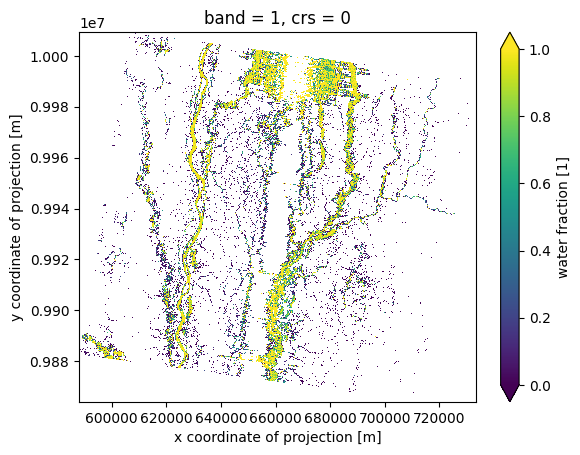

In [36]:
patch.where(~no_pixels_np)["water_frac"].squeeze().plot.imshow(vmin=0, vmax=1)

In [39]:
patch["water_frac"] = patch["water_frac"].where(~no_pixels_np)

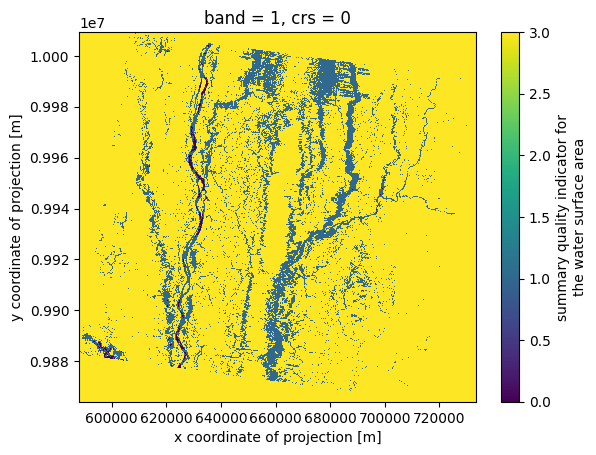

In [41]:
patch["water_area_qual"].plot()